# Learning **COMPAS** for the first time
The main goal of this notebook is to serve as an introductory lesson on how to use **COMPAS** for the first time, along with a few applications. The basics you will know by the end of this tutorial include:
-   Understanding how **COMPAS** handles input parameters (.yaml file)

-   Customizing your own configuration file
-   Running your first **COMPAS** simulation
-   Understanding the system **COMPAS** uses for its output data (.h5 file)
-   Accessing a **COMPAS** output file and extracting a dataframe from a group

But that's not all! Once you grasp the very basics of how to use **COMPAS**, this handbook will show just a few of the ways **COMPAS** can be used to investigate properties of Binary Population Synthesis (BPS) and Binary Stellar Evolution (BSE). The main aims of this advanced section include:
-   Plotting properties extracted from an .h5 output file

-   Creating and applying masks to filter out unwanted binary systems
-   Creating flags for dataframes based on the properties of a binary system
-   Running a set of multiple **COMPAS** simulations with ranging initial parameters
-   Overwriting .h5 output files

## The Basics
We will begin by importing a range of libraries which will be useful for any work related to COMPAS:
-   `numpy` and `pyplot` are used for plotting

-   `h5py` will be needed for reading and writing COMPAS output data
-   `yaml` will be needed for reading and writing COMPAS input data
-   `pandas` is used for all kinds of data analysis and manipulation
-   `subprocess` allows for COMPAS to run inside python code as opposed to going directly to shell
-   `Path` helps with getting directories for different files

Other libraries can also be useful later on, but these are necessary for doing anything with COMPAS

In [34]:
import subprocess 
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import h5py
import yaml
from pathlib import Path 
import shutil

### What is **COMPAS**?
**COMPAS** (Compact Object Mergers: Population Astrophysics and Statistics) is a publicly available rapid binary population synthesis code we will use to create and evolve our populations of binary stars, details can be found [here](https://compas.science). 

Before continuing with this handbook that will introduce you to **COMPAS**, you must first install **COMPAS** on your machine. The instructions for installing **COMPAS** can be found [here](https://compas.readthedocs.io/en/latest/pages/Getting%20started/getting-started.html).

### The **COMPAS** Process
1. Sampling initial conditions/population property distributions specified by the user

2. Evolves stars through each evolutionary phase using analytic formulas
3. Simulates binary interactions such as mass transfer, supernova, common envelopes, etc. via parameterized prescriptions which the user can specify (e.g. changing the mass transfer efficiency parameter)
4. Records outcomes of binaries after binary interactions

### **COMPAS** Output structure
After evolving the entire population **COMPAS** returns its output as a folder called `COMPAS_Output` which contains the results file: `COMPAS_Output.h5`, an HDF5 file which contains the following groups which can each be accessed individually as we will see later on:
-   `BSE_System_Parameters`: data group containing initial + final states of binaries
-   `BSE_Common_Envelopes`: details of each binary's common envelope event(s)
-   `BSE_RLOF`: details of each binary's mass transfer event(s) (everytime a companion overflows its Roche lobe)
-   `BSE_Supernovae`: details of each binary's supernova event(s)
-   `BSE_Double_Compact_Objects`: details for binary's ending as BBH, BNS, BHNS

To fully understand how an HDF5 file works, think of its heirarchy as this:
-   `COMPAS_Output.h5`
    -   `BSE_System_Parameters`
        -   `Stellar_Type(1)@ZAMS`
        -   `Stellar_Type(2)@ZAMS`
        -   `SemiMajorAxis@ZAMS`
        -   ...
    -   `BSE_Common_Envelopes`
        -   `Merger`
        -   `RLOF(1)`
        -   `Hydrogen_Abundance_Core(1)`
        -   ...
    -   `BSE_RLOF`
        -   ...
    -   `BSE_Supernovae`
        -   ...
    -   `BSE_Double_Compact_Objects`
        -   ...

For further information on **COMPAS** outputs, see the documentation's [output section here](https://compas.readthedocs.io/en/latest/pages/User%20guide/COMPAS%20output/output.html).

A few important things to know as you use **COMPAS**
-   In a single **COMPAS** simulation, every single binary system is given a unique `SEED` value. This is a value used to identify systems accross different dataframes. A ***very*** important thing to note is that `SEED` is ***not*** always unique in any output group!! For instance, let's say that system `#732` underwent *two* different common envelope (CE) events. Then, the `BSE_Common_Envelopes` dataframe would include two seperate rows for this system, each for a seperate CE event, and **both** rows will have the same `SEED` value of `732`. One output group that ***always*** has unique `SEED` values is `BSE_System_Parameters`, as it contains a single row for each system that was simulated, regardless of what happens to that system throughout its evolution.

-   **COMPAS** differentiates the primary star from the secondary star using `(1)` and `(2)`, respectively. For instance, for a parameter like initial mass, there would be `Mass@ZAMS(1)`, representing the initial mass of the ***primary*** star, and `Mass@ZAMS(2)`, representing the initial mass of the ***secondary*** star.

### **COMPAS** Input Parameters

**COMPAS** has a wide range of different parameters that the user can specify via the configuration file that you send to **COMPAS** when running a simulation. The default `compasConfigDefault.yaml` file can be found in this repository or by clicking here. Let's load the default configuration file to see what parameters we can play with.

In [35]:
with open(*Path.cwd().rglob("compasConfigDefault.yaml"), "r") as file: print(file.read())

##~!!~## COMPAS option values
##~!!~## File Created Mon Feb  2 10:03:24 2026 by COMPAS v03.29.00
##~!!~##
##~!!~## The default COMPAS YAML file (``compasConfigDefault.yaml``), as distributed, has
##~!!~## all COMPAS option entries commented so that the COMPAS default value for the
##~!!~## option is used by default. To use a value other than the COMPAS default value,
##~!!~## users must uncomment the entry and change the option value to the desired value.

booleanChoices:

    ### LOGISTICS
#    --debug-to-file: False                                                # Default: False
#    --detailed-output: False                                              # Default: False                                                                                                                                                                            # WARNING! this creates a data heavy file
#    --emit-gravitational-radiation: False                                 # Default: False
#    --enable-w

That's a lot of different parameters! One thing to note is that **COMPAS** comments out all its parameters in the `compasConfigDefault.yaml` file so that simulations are run with default values. To change a certain parameter, uncomment the line and change the value of the parameter in the configuration file.
> **NOTE**: As an important habit to form when working with **COMPAS**, *always* keep the default configuration file clean and unmodified. Then, create a *new* config file as a copy from the default, without editing the default.

In this repository, you should be able to find the file `compasConfig_v1.yaml`, which is a custom configuration file with a few of the parameters changed:
-   `--number_of_systems`: Set to **$n = 1000$** instead of the default **$n = 10$**
-   `--metallicity`: Set to **$Z = 0.0001$** instead of the defualt **$Z = 0.0142$**
-   `--common-envelope-alpha`: Set to **$\alpha_{CE} = 0.50$** instead of the deafault **$\alpha_{CE} = 1.0$**
-   `--random-seed`: Set to a certain value, in this case 42

Try looking at the new `compasConfig_v1.yaml` file and see the changes. Let's also print it out below:
> **NOTE**: Notice how it doesn't print out parameters that have not been touched. That's because they are still commented out in the config file

In [36]:
with open('compasConfig_v1.yaml', 'r') as file: print(yaml.dump(yaml.safe_load(file), default_flow_style=False))

booleanChoices: null
listChoices: null
numericalChoices:
  --common-envelope-alpha: 0.5
  --metallicity: 0.0001
  --number-of-systems: 1000
  --random-seed: 42
stringChoices: null



### Running your first **COMPAS** simulation

For **COMPAS** to run a simulation, all it needs is configuration file to be fed in and it can start simulating a population of binary systems with the parameters pulled straight from that configuration file that it received. **COMPAS** can also be modified to tweak its back-end code but that's beyond the scope of this handbook. We will use the `subprocess` library which allows us to run terminal code right here in a python environment.

In [37]:
base_config_path = 'compasConfigDefault.yaml'
cfg_path = 'compasConfig_v1.yaml'

with open(base_config_path, "r") as f: base_config = yaml.safe_load(f)
with open(cfg_path, "r") as f: cfg = yaml.safe_load(f)

proc = subprocess.run(
    ["compas_run_submit", str(Path(cfg_path))],
    capture_output=True, text=True,
)

Great! You should be able to see a `COMPAS_Output` folder in your working directory now. Go ahead and find the `HDF5` output file in that folder. Next, we will look into how we can access and look into the output of the simulation that was just ran.

### Accessing a **COMPAS** Output File

Since **COMPAS** stores its outputs in `HDF5` files, we will want to convert these into usable `pandas` dataframes so that we can analyze, manipulat, and investigate the data. The code below is a helper function which will make accessing the several **COMPAS** groups much easier,

In [38]:
# Loads a COMPAS output file group as a pandas dataframe    
def load_compas_group(h5_path, group_name):
    if not Path(h5_path).exists(): print(f"No file found with path: {h5_path}"); return
    data = {}
    with h5py.File(h5_path, 'r') as f:
        group = f[group_name]
        for col in group.keys():
            data[col] = group[col][:]
    df = pd.DataFrame(data)
    for col in df.columns:
        if df[col].dtype == object:
            df[col] = df[col].apply(lambda x: x.decode('utf-8') if isinstance(x, bytes) else x)
    return df

As mention earlier above, there are a set of several different groups contained in a single **COMPAS** `HDF5` file. For now, let's investigate the `BSE_System_Parameters` file and see what each binary system looks like when initialized.

In [39]:
sys_param_df = load_compas_group('COMPAS_Output/COMPAS_Output.h5',
                                 'BSE_System_Parameters')

sys_param_df.head(10)

,CH_on_MS(1),CH_on_MS(2),Eccentricity@ZAMS,Equilibrated_At_Birth,Error,Evolution_Status,Mass@ZAMS(1),Mass@ZAMS(2),Merger,Merger_At_Birth,...,Record_Type,SEED,SN_Kick_Magnitude_Random_Number(1),SN_Kick_Magnitude_Random_Number(2),SemiMajorAxis@ZAMS,Stellar_Type(1),Stellar_Type(2),Stellar_Type@ZAMS(1),Stellar_Type@ZAMS(2),Unbound
0,0,0,0.0,0,43,12,5.416431,0.365624,1,0,...,1,42,0.796543,0.950714,1.978083,5,0,1,0,0
1,0,0,0.0,1,43,12,4.427263,4.427263,1,0,...,1,43,0.496861,0.609067,0.016798,1,1,1,1,0
2,0,0,0.0,0,43,15,6.263390,2.504365,0,0,...,1,44,0.432542,0.104796,25.097195,12,11,1,1,0
3,0,0,0.0,0,43,3,8.209055,0.476427,0,0,...,1,45,0.304536,0.549545,39.662997,13,0,1,0,1
4,0,0,0.0,0,43,12,12.963340,0.679756,1,0,...,1,46,0.258047,0.634834,0.027398,1,0,1,0,0
5,0,0,0.0,0,43,12,35.560663,23.082648,1,0,...,1,47,0.851757,0.974483,0.950272,4,1,1,1,0
6,0,0,0.0,0,43,17,7.327586,6.346153,0,0,...,1,48,0.426484,0.891573,2.499422,13,13,1,1,1
7,0,0,0.0,0,43,15,5.141652,2.835602,0,0,...,1,49,0.473737,0.247062,49.968815,12,11,1,1,0
8,0,0,0.0,0,43,14,45.432704,18.814374,0,0,...,1,50,0.129175,0.228083,105.538949,14,14,1,1,0
9,0,0,0.0,0,43,3,8.613415,1.430632,0,0,...,1,51,0.327111,0.044712,135.193485,13,11,1,1,1


And just to see some other groups, let us also look into `BSE_Common_Envelopes`, which tracks common envelope (CE) events between binaries. Again, please check the note above regarding the `SEED` parameter.

In [40]:
ce_df = load_compas_group('COMPAS_Output/COMPAS_Output.h5',
                          'BSE_Common_Envelopes')

ce_df.head(10)

,BE_Fixed(1),BE_Fixed(2),BE_Kruckow(1),BE_Kruckow(2),BE_Loveridge(1),BE_Loveridge(2),BE_Loveridge_Winds(1),BE_Loveridge_Winds(2),BE_Nanjing(1),BE_Nanjing(2),...,Tau_Radial<CE(2),Tau_Sync(1),Tau_Sync(2),Tau_Thermal<CE(1),Tau_Thermal<CE(2),Teff<CE(1),Teff<CE(2),Time,Zeta_Lobe,Zeta_Star
0,0.000000e+00,1.558755e+49,0.000000e+00,3.972445e+46,0.000000e+00,1.558755e+48,0.000000e+00,1.558755e+48,0.000000e+00,1.558755e+48,...,1.046892e+06,0.0,0.0,1.030347e-04,443.498679,4358.843906,4182.361737,84.368968,26.576573,0.177194
1,4.819119e+50,4.819119e+50,3.466745e+48,3.466745e+48,4.819119e+49,4.819119e+49,4.819119e+49,4.819119e+49,4.819119e+49,4.819119e+49,...,-1.000000e+00,0.0,0.0,8.713938e-01,0.871394,21509.629951,21509.629951,0.000000,0.000000,0.000000
2,1.721885e+51,2.899345e+49,2.218906e+49,1.116837e+47,1.721885e+50,2.899345e+48,1.721885e+50,2.899345e+48,1.721885e+50,2.899345e+48,...,1.856284e+05,0.0,0.0,7.784867e-02,92.470448,34933.933356,5302.336297,8.412412,35.288612,2.000000
3,-1.025312e+34,3.058216e+51,-1.076965e+33,5.773602e+49,-1.025312e+33,3.058216e+50,-1.025312e+33,3.058216e+50,-2.763577e+33,3.058216e+50,...,6.876047e+00,0.0,0.0,5.205476e-04,0.023762,16833.744272,40744.854556,6.046913,0.862137,0.273777
4,0.000000e+00,5.773889e+51,0.000000e+00,3.514881e+49,0.000000e+00,5.773889e+50,0.000000e+00,5.773889e+50,0.000000e+00,1.907568e+51,...,5.892427e-02,0.0,0.0,6.149660e-18,0.000068,2364.168692,6434.592062,7.767790,2.337411,0.315938
5,5.089784e+51,1.441627e+51,1.343258e+50,1.516744e+49,5.089784e+50,1.441627e+50,5.089784e+50,1.441627e+50,5.089784e+50,1.441627e+50,...,6.331272e+01,0.0,0.0,1.123236e-02,0.170496,43413.268419,31981.631528,4.460051,5.133602,2.000000
6,0.000000e+00,3.091161e+50,0.000000e+00,2.203434e+48,0.000000e+00,3.091161e+49,0.000000e+00,3.091161e+49,0.000000e+00,3.091161e+49,...,4.249740e+02,0.0,0.0,3.289312e-05,0.997618,4202.631610,18737.677985,60.795146,1.083471,0.017563
7,8.956648e+50,1.411040e+51,9.795660e+48,1.506349e+49,8.956648e+49,1.411040e+50,8.956648e+49,1.411040e+50,8.956648e+49,1.411040e+50,...,5.939083e+01,0.0,0.0,1.456151e-01,0.160529,28689.894880,31942.351234,12.278381,1.369292,2.000000
8,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,5.510115e-01,0.0,0.0,4.457712e-14,0.000014,19518.918925,4092.972895,125.886777,7.740070,0.062604
9,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,2.371909e-01,0.0,0.0,4.441990e-14,0.000099,12592.669617,4350.864516,123.642352,8.506866,0.173681


And there you go! With this information, you now have the ability to run your own **COMPAS** simulations with any set of parameters you choose, as well as access its various output groups and parameters it stores! In the following section of this handbook, we will teach a few more advanced skills that will be very helpful for more in-depth **COMPAS** work.

## More Advanced **COMPAS** Techniques

In this section, you will learn how to use **COMPAS** more effectively and creating better workflows that will allow for a simpler and smoother **COMPAS** experience.

### Common Helper Functions

Having a set of helper functions is always a good habit to not only simplify code structure, but also to make repetitive tasks, such as opening `.yaml` files and adding **COMPAS** options. Below is a set of basic helper functions that will be helpful for our **COMPAS** analysis in the future.

-   `load_yaml(path)` *Loads a .yaml file from the path provided*


-   `save_yaml(obj, path)` *Saves a .yaml file into the path provided*
-   `move_outputs(folder_to_save, folder_from='')` *Moves **COMPAS** outputs from one folder to another (if no source folder is provided, it pulls **COMPAS** outputs straight from the working directory)*
-   `set_compas_option(cfg, key, value)` *Overwrites a **COMPAS** .yaml config file*
-   `load_compas_group(h5_path, group_name)` *Loads in a **COMPAS** group as a pandas dataframe* 

In [41]:
def load_yaml(path):
    if not Path(path).exists(): print(f"No file found with path: {path}"); return
    with open(path, "r") as f:
        return yaml.safe_load(f)

def save_yaml(obj, path):
    with open(path, "w") as f:
        yaml.safe_dump(obj, f, sort_keys=False)
        
def move_outputs(folder_to_save, folder_from=''):
    if not Path(folder_to_save).exists(): print(f"No file found with path: {folder_to_save}"); return
    if not Path(folder_from).exists(): print(f"No file found with path: {folder_from}"); return
    base_path = Path.cwd() / folder_from if folder_from else Path.cwd()
    folder_paths = [str(x) for x in list(base_path.glob("COMPAS_Output*"))]
    if folder_paths == []: print(f"No output folders found."); return
    for folder in folder_paths:
        shutil.move(folder, folder_to_save)
    print(f"Successfully moved {len(folder_paths)} folders from {"working directory" if folder_from == '' else folder_from} to {folder_to_save}")

# Sets a COMPAS .yaml config file option
def set_compas_option(cfg, key, value):
    """Insert a key/value into the correct yaml block based on Python type."""
    if isinstance(value, bool):
        section = "booleanChoices"
    elif isinstance(value, (int, float)):
        section = "numericalChoices"
    elif isinstance(value, str):
        section = "stringChoices"
    else:
        raise TypeError(f"unsupported value type for {key}: {type(value)}")

    if cfg.get(section) is None:   # handles both "missing" and "present but None"
        cfg[section] = {}
    cfg[section][key] = value
    
# Loads a COMPAS output file group as a pandas dataframe    
def load_compas_group(h5_path, group_name):
    if not Path(h5_path).exists(): print(f"No file found with path: {h5_path}"); return
    data = {}
    with h5py.File(h5_path, 'r') as f:
        group = f[group_name]
        for col in group.keys():
            data[col] = group[col][:]
    df = pd.DataFrame(data)
    for col in df.columns:
        if df[col].dtype == object:
            df[col] = df[col].apply(lambda x: x.decode('utf-8') if isinstance(x, bytes) else x)
    return df

### Running **COMPAS** More Effectively

The technique provided in the previous section of this handbook would run **COMPAS** directly by using a predefined configuration `.yaml` file. Doing that every time you want to run a **COMPAS** simulation would be very tiresome and inefficient. Let's create an efficient function to run a **COMPAS** simulation much smoother. First, we will want this function to take in a set of the parameters we want to change and create a custom `config.yaml` file with the parameters we are changing. This input will have to be `dict` dictionary so that **COMPAS** knows what parameter is being changed and what value it is being replaced with. To make things easier, we will also want it to give the option to move the output it produces into a specific folder. By default the function should keep it in the main working directory. Let's go ahead and build this function now.

In [42]:
def run_custom_case(parameters = {}, folder_to_send = ''):
    if parameters == {}: 
        print("No parameters given, running default COMPAS parameters")
    
    custom_config_name = "parameters_"
    custom_config = load_yaml('compasConfigDefault.yaml')
    for key in parameters.keys():
        custom_config_name += f"__{key}_{parameters[key]}"
        set_compas_option(custom_config, f"--{key}", parameters[key])
        
    custom_config_path = Path(f"config_{custom_config_name}.yaml")
    save_yaml(custom_config, custom_config_path)
    
    before = set(Path(".").glob("COMPAS_Output*")) # Used in later section

    proc = subprocess.run(
        ["compas_run_submit", str(custom_config_path)],
        capture_output=True, text=True,
    ) 

    if proc.returncode != 0 or "error" in proc.stderr.lower():
        print(f"FAILED [{custom_config_name}]:\n{proc.stderr}")
        return None
    else:
        print(f"Succesfully ran COMPAS simulation: {custom_config_name}")
        
    # More advanced section to return the .h5 file output and add simulation details
    after = set(Path(".").glob("COMPAS_Output*"))
    
    new_sims = list(after - before)[0]
    h5_files = list(new_sims.glob("**/*.h5"))
    
    (h5_files[0].parent / f"{custom_config_name}.txt").touch()
    
    custom_config_path.unlink()

    return h5_files[0]

Now let's put this function to use! We will run a simulation using this new function with the same parameters as before and we should be able to get the same results.

In [43]:
dict = {'metallicity' : 0.0001,
        'number-of-systems' : 1000,
        'common-envelope-alpha' : 0.50,
        'random-seed': 7}

h5_output_path = run_custom_case(dict)

sys_param_df = load_compas_group(h5_output_path,
                                 'BSE_System_Parameters')

sys_param_df.head(10)

Succesfully ran COMPAS simulation: parameters___metallicity_0.0001__number-of-systems_1000__common-envelope-alpha_0.5__random-seed_7


,CH_on_MS(1),CH_on_MS(2),Eccentricity@ZAMS,Equilibrated_At_Birth,Error,Evolution_Status,Mass@ZAMS(1),Mass@ZAMS(2),Merger,Merger_At_Birth,...,Record_Type,SEED,SN_Kick_Magnitude_Random_Number(1),SN_Kick_Magnitude_Random_Number(2),SemiMajorAxis@ZAMS,Stellar_Type(1),Stellar_Type(2),Stellar_Type@ZAMS(1),Stellar_Type@ZAMS(2),Unbound
0,0,0,0.0,0,43,12,6.307791,3.192431,1,0,...,1,7,0.227339,0.779919,0.027147,1,1,1,1,0
1,0,0,0.0,0,43,3,10.209605,4.453063,0,0,...,1,8,0.011114,0.968541,67.657298,13,11,1,1,1
2,0,0,0.0,0,43,12,23.557534,9.996006,1,0,...,1,9,0.364461,0.501875,0.048712,1,1,1,1,0
3,0,0,0.0,0,43,15,5.097805,1.050567,0,0,...,1,10,0.298761,0.020752,35.159286,12,11,1,1,0
4,0,0,0.0,0,43,3,6.071022,0.137527,0,0,...,1,11,0.068307,0.019475,303.182232,12,0,1,0,0
5,0,0,0.0,0,43,12,5.133015,4.628480,1,0,...,1,12,0.446222,0.740050,0.300043,8,6,1,1,0
6,0,0,0.0,0,43,17,14.203222,8.705894,0,0,...,1,13,0.607341,0.237541,10.882201,13,13,1,1,1
7,0,0,0.0,0,43,15,6.049032,3.133311,0,0,...,1,14,0.921893,0.773165,0.395483,11,11,1,1,0
8,0,0,0.0,0,43,15,5.096936,1.594626,0,0,...,1,15,0.813580,0.178896,129.267844,12,11,1,1,0
9,0,0,0.0,0,43,15,5.676389,3.927147,0,0,...,1,16,0.326656,0.523163,18.582925,12,11,1,1,0


In [44]:
load_compas_group('COMPAS_Output/COMPAS_Output.h5', 'BSE_System_Parameters').head(10)

,CH_on_MS(1),CH_on_MS(2),Eccentricity@ZAMS,Equilibrated_At_Birth,Error,Evolution_Status,Mass@ZAMS(1),Mass@ZAMS(2),Merger,Merger_At_Birth,...,Record_Type,SEED,SN_Kick_Magnitude_Random_Number(1),SN_Kick_Magnitude_Random_Number(2),SemiMajorAxis@ZAMS,Stellar_Type(1),Stellar_Type(2),Stellar_Type@ZAMS(1),Stellar_Type@ZAMS(2),Unbound
0,0,0,0.0,0,43,12,5.416431,0.365624,1,0,...,1,42,0.796543,0.950714,1.978083,5,0,1,0,0
1,0,0,0.0,1,43,12,4.427263,4.427263,1,0,...,1,43,0.496861,0.609067,0.016798,1,1,1,1,0
2,0,0,0.0,0,43,15,6.263390,2.504365,0,0,...,1,44,0.432542,0.104796,25.097195,12,11,1,1,0
3,0,0,0.0,0,43,3,8.209055,0.476427,0,0,...,1,45,0.304536,0.549545,39.662997,13,0,1,0,1
4,0,0,0.0,0,43,12,12.963340,0.679756,1,0,...,1,46,0.258047,0.634834,0.027398,1,0,1,0,0
5,0,0,0.0,0,43,12,35.560663,23.082648,1,0,...,1,47,0.851757,0.974483,0.950272,4,1,1,1,0
6,0,0,0.0,0,43,17,7.327586,6.346153,0,0,...,1,48,0.426484,0.891573,2.499422,13,13,1,1,1
7,0,0,0.0,0,43,15,5.141652,2.835602,0,0,...,1,49,0.473737,0.247062,49.968815,12,11,1,1,0
8,0,0,0.0,0,43,14,45.432704,18.814374,0,0,...,1,50,0.129175,0.228083,105.538949,14,14,1,1,0
9,0,0,0.0,0,43,3,8.613415,1.430632,0,0,...,1,51,0.327111,0.044712,135.193485,13,11,1,1,1


Same results! In the future, it is much better to use this modular and smoother function `run_custom_case` function for **COMPAS** runs. Not only does it avoid needing to create a new `.yaml` config file, but it also keeps the original `compasConfigDefault.yaml` file fully pristine.

### Analyzing **COMPAS** Outputs and Creating Masks

Now that we can easily run **COMPAS** and generate results, it is time to actually put those outputs to use! We can begin by creating *masks*, which allow us to select only certain systems that match conditions that we choose. Learning how to create masks is crucial for future **COMPAS** analysis, since it will also allow us to see patterns in the BSE population. The first mask we will create is to isolate only *Stellar* systems: systems that only involve stars rather than compact objects (COs). Find the `Stellar_Type` parameter inside the `BSE_System_Parameters` dataframe. For our purposes, stellar objects are classified as any system where both stars have a `Stellar_Type <= 9`. Let's go ahead and make that mask now.

In [45]:
sys_param_df = load_compas_group(h5_output_path,
                                 'BSE_System_Parameters')

stellar_mask = (
    (sys_param_df['Stellar_Type(1)'] <= 9) &
    (sys_param_df['Stellar_Type(2)'] <= 9)
)

stellar_sys_param_df = sys_param_df[stellar_mask]
print(f"There are {len(stellar_sys_param_df)} stellar systems")

There are 333 stellar systems


### Creating Flags and Custom Dataframes

Most of the time, we won't need the entire set of parameters of a **COMPAS** output file. Thus, it's useful to combine our masking technique with a *flagging* habit that helps with analysis for creating dataframes. We will repeat the same exercise in the previous section, but this time we will not be isolating systems, but adding the `Stellar_Type` as an extra flag or column in a new dataframe.

In [46]:
sys_param_df = load_compas_group(h5_output_path,
                                 'BSE_System_Parameters')

stellar_mask = (
    (sys_param_df['Stellar_Type(1)'] <= 9) &
    (sys_param_df['Stellar_Type(2)'] <= 9)
)

custom_df = sys_param_df
custom_df['Stellar'] = stellar_mask

For this handbook, we want to analyze how `Mass@ZAMS(1)` (the mass of the primary star at ZAMS) relates to binary systems merging. In order to do this, we will first use that newly created `Stellar` mask. Then, we will isolate the `Mass@ZAMS(1)` and `Merger` parameters and create a new `Stellar_Merger` flag. This will be used in the next section to plot out our very first graph.

In [47]:
custom_df = custom_df[['Mass@ZAMS(1)', 'Merger', 'Stellar']]
custom_df['Stellar_Merger'] = (custom_df['Merger'] == 1) & custom_df['Stellar']

mass_merger_df = custom_df[['Mass@ZAMS(1)', 'Stellar_Merger']]
mass_merger_df = mass_merger_df[mass_merger_df['Stellar_Merger']]

mass_merger_df.head(10)

,Mass@ZAMS(1),Stellar_Merger
0,6.307791,True
2,23.557534,True
5,5.133015,True
11,5.044169,True
12,5.158384,True
16,5.834381,True
17,15.898571,True
25,6.959053,True
27,14.613299,True
29,31.985303,True


### Basic Plotting

Since this is mainly a handbook focusing on teaching how to use **COMPAS** effectively, we will not dwell too much on how to use `matplotlib` to create plots. Shown below is a basic histogram that shows how the masses of the primary star in binary stellar mergers is distributed.

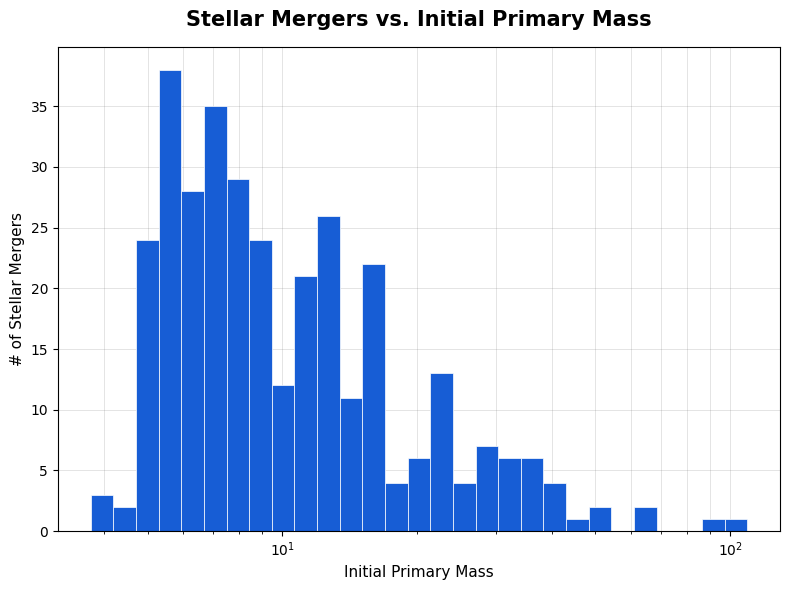

In [48]:
fig, ax = plt.subplots(figsize=(8, 6))

bins = np.logspace(np.log10(mass_merger_df['Mass@ZAMS(1)'].min() + 0.1), np.log10(mass_merger_df['Mass@ZAMS(1)'].max()), 30)
ax.hist(mass_merger_df['Mass@ZAMS(1)'], bins=bins, color="#175DD5", edgecolor="white", linewidth=0.5)

ax.set_xscale("log") # Log x-axis

# Labels & title
ax.set_xlabel("Initial Primary Mass", fontsize=11)
ax.set_ylabel("# of Stellar Mergers", fontsize=11)
ax.set_title("Stellar Mergers vs. Initial Primary Mass", fontsize=15, fontweight="bold", pad=15)

# Gridlines - light, behind bars
ax.grid(True, which="both", axis="both", color="gray", alpha=0.25, linewidth=0.6)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

## Parameter Variation
One of the most useful techniques to learn in **COMPAS** is knowing how to run a set of simulations with different initial parameters. This allows you to view trends accross a range of initial conditions, allowing for much more in-depth analysis. For this handbook, we will focus on ranging through a set of three different initial *metallicities*, and then investigate how that affects binaries. The process is actually quite simple since the function we created earlier, `run_custom_case`, is very modular and allows for parameters to be easily passed into a **COMPAS** simulation. Let's create a simple loop that will range through the following metallicites: $0.0001, 0.001$, and $0.01$. For now, we can track the number of stellar mergers for each metallicity.

In [ ]:
metallicity_merger_df = pd.DataFrame(columns=['metallicity', 'stellar_mergers'])
metallicites = [0.0001, 0.001, 0.01]

dict = {'number-of-systems' : 1000,
        'common-envelope-alpha' : 0.50,
        'random-seed': 7}

stellar_mask = (
    (sys_param_df['Stellar_Type(1)'] <= 9) &
    (sys_param_df['Stellar_Type(2)'] <= 9)
)

for metallicity in metallicites:
    dict['metallicity'] = metallicity
    
    h5_output_path = run_custom_case(dict)
    sys_param_df = load_compas_group(h5_output_path, 'BSE_System_Parameters')
        
    sys_param_df['Stellar'] = stellar_mask
    sys_param_df['Stellar_Merger'] = (sys_param_df['Merger'] == 1) & (sys_param_df['Stellar'] == True)
        
    row = pd.DataFrame([{'metallicity' : metallicity,
                         'stellar_mergers' : len(sys_param_df[sys_param_df['Stellar_Merger']])}])
    
    metallicity_merger_df = pd.concat([metallicity_merger_df, row], ignore_index=True)
    
metallicity_merger_df.head(len(metallicites))

Succesfully ran COMPAS simulation: parameters___number-of-systems_1000__common-envelope-alpha_0.5__random-seed_7__metallicity_0.0001
   metallicity  stellar_mergers
0       0.0001              333
Succesfully ran COMPAS simulation: parameters___number-of-systems_1000__common-envelope-alpha_0.5__random-seed_7__metallicity_0.001
   metallicity  stellar_mergers
0        0.001              296


KeyboardInterrupt: 

Now, we can see that as the metallicity of a binary system increases, the number of stellar mergers decreases!

One last thing to note as we end this **COMPAS** tutorial is that as you begin running simulations with more systems and varying more parameters, computation time significantly increases. Depending on your hardware and how many **COMPASS** simulations you are running and also the number of systems, certain runs could take up to a few hours to run. Moreover, as you have probably noticed, $n = 1000$ systems is too few to produce accurate patterns, and finer parameter variation is always better to find trends in the data.